# Multi-seed Van der Pol learning experiment

- `resnet`: untied residual baseline
- `node_euler`: shared-vector-field fixed-step Neural ODE with Euler
- `node_rk4`: shared-vector-field fixed-step Neural ODE with RK4

A reduced-width auxiliary residual baseline is trained separately as a fairness check and is **not**
mixed into the main comparison tables.


In [1]:
import os
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


## CPU settings and global options

In [2]:
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

try:
    torch.set_num_threads(1)
except RuntimeError as e:
    print(f"Warning: torch.set_num_threads could not be applied ({e})")

try:
    torch.set_num_interop_threads(1)
except RuntimeError as e:
    print(f"Warning: torch.set_num_interop_threads could not be applied ({e})")

device = torch.device("cpu")
print("device:", device)


device: cpu


## Experiment parameters

In [3]:
# ----------------------------
# User-adjustable parameters
# ----------------------------
SEEDS = [0, 1, 2, 3, 4]

# Van der Pol parameter
MU = 3.0

# Time grid used for dataset generation and training
T0, T1 = 0.0, 10.0
N_TIME = 101
T_EVAL = np.linspace(T0, T1, N_TIME, dtype=np.float64)
N_STEPS = N_TIME - 1
DT = float(T_EVAL[1] - T_EVAL[0])

# Dense grids used only for visualization (do not affect training)
N_TIME_PLOT = 4001
T_EVAL_PLOT = np.linspace(T0, T1, N_TIME_PLOT, dtype=np.float64)

PHASE_TRAJ_T1 = 30.0
N_TIME_PHASE = 6001
T_EVAL_PHASE = np.linspace(T0, PHASE_TRAJ_T1, N_TIME_PHASE, dtype=np.float64)

PHASE_FIELD_XLIM = (-2.5, 2.5)
PHASE_FIELD_VLIM = (-8.0, 8.0)
PHASE_FIELD_N = 25

# Marker settings for discrete model rollouts in phase space
PHASE_MARK_EVERY = max(1, N_TIME // 20)
PHASE_MARKER_SIZE = 3.0

# Dataset sizes
N_TRAIN = 256
N_VAL = 64
N_TEST = 64

INIT_LOW = np.array([-2.5, -2.5], dtype=np.float32)
INIT_HIGH = np.array([2.5, 2.5], dtype=np.float32)

# Optimization
BATCH_SIZE = 32
EPOCHS = 150
LR = 1e-3
WEIGHT_DECAY = 1e-6

# Main model sizes
HIDDEN_DIM = 64
RESNET_BLOCKS = N_STEPS
NODE_HIDDEN_DIM = 64

# Auxiliary fairness diagnostic:
# width 4 gives ~4200 parameters, close to the ~4482-parameter main NODE baseline.
INCLUDE_FAIRNESS_DIAGNOSTIC = True
FAIR_RESNET_HIDDEN_DIM = 4

# Whether to save per-seed histories
SAVE_HISTORIES = True

# Reference seed / initial condition for exported comparison figures
REFERENCE_SEED = SEEDS[0]
REFERENCE_Z0 = np.array([2.0, 0.0], dtype=np.float32)

# Cost-counting convention:
# total_fit_forward_evals = forward_evals_per_traj * N_TRAIN * EPOCHS
# i.e. forward operator evaluations over training trajectories only.
FIT_EVAL_COUNTING_RULE = "train_only"

MAIN_MODEL_ORDER = ["resnet", "node_euler", "node_rk4"]
FAIRNESS_MODEL_ORDER = ["resnet_fair"]

preferred_results_dir = Path("results/learning/van_der_pol_multiseed")
fallback_results_dir = Path("van_der_pol_multiseed_results")

try:
    preferred_results_dir.mkdir(parents=True, exist_ok=True)
    RESULTS_DIR = preferred_results_dir
except PermissionError:
    RESULTS_DIR = fallback_results_dir
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    print("Warning: preferred results directory was not writable; using fallback directory instead.")


print("MU =", MU)
print("Training horizon T in [{:.1f}, {:.1f}]".format(T0, T1))
print("Training grid N_TIME =", N_TIME)
print("Training grid DT =", DT)
print("Dense plotting grid N_TIME_PLOT =", N_TIME_PLOT)
print("Phase portrait horizon PHASE_TRAJ_T1 =", PHASE_TRAJ_T1)
print("seeds =", SEEDS)
print("fairness diagnostic enabled =", INCLUDE_FAIRNESS_DIAGNOSTIC)

MU = 3.0
Training horizon T in [0.0, 10.0]
Training grid N_TIME = 101
Training grid DT = 0.1
Dense plotting grid N_TIME_PLOT = 4001
Phase portrait horizon PHASE_TRAJ_T1 = 30.0
seeds = [0, 1, 2, 3, 4]
fairness diagnostic enabled = True


## Utility: reproducibility

In [4]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


## True system and dataset generation

In [5]:
def van_der_pol(t, z, mu=MU):
    x, v = z
    dx = v
    dv = mu * (1.0 - x**2) * v - x
    return np.array([dx, dv], dtype=np.float64)

def solve_true_trajectory(z0, t_eval=T_EVAL, mu=MU):
    sol = solve_ivp(
        fun=lambda t, z: van_der_pol(t, z, mu=mu),
        t_span=(float(t_eval[0]), float(t_eval[-1])),
        y0=np.asarray(z0, dtype=np.float64),
        t_eval=t_eval,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
    )
    if not sol.success:
        raise RuntimeError(f"Trajectory generation failed: {sol.message}")
    return sol.y.T.astype(np.float32)

def sample_initial_conditions(n, low=INIT_LOW, high=INIT_HIGH):
    return np.random.uniform(low=low, high=high, size=(n, 2)).astype(np.float32)

def make_dataset(n_samples):
    z0s = sample_initial_conditions(n_samples)
    trajectories = np.stack([solve_true_trajectory(z0) for z0 in z0s], axis=0)
    return z0s, trajectories

def make_dataloaders(train_z0, train_traj, val_z0, val_traj, test_z0, test_traj):
    train_ds = TensorDataset(torch.from_numpy(train_z0), torch.from_numpy(train_traj))
    val_ds = TensorDataset(torch.from_numpy(val_z0), torch.from_numpy(val_traj))
    test_ds = TensorDataset(torch.from_numpy(test_z0), torch.from_numpy(test_traj))

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, val_loader, test_loader


## Models

In [6]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, depth=2, activation=nn.Tanh):
        super().__init__()
        layers = []
        dims = [in_dim] + [hidden_dim] * depth + [out_dim]
        for i in range(len(dims) - 2):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(activation())
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class ResidualBlock(nn.Module):
    def __init__(self, state_dim=2, hidden_dim=HIDDEN_DIM, dt=DT):
        super().__init__()
        self.dt = dt
        self.f = MLP(state_dim, hidden_dim, state_dim, depth=2, activation=nn.Tanh)

    def forward(self, z):
        return z + self.dt * self.f(z)

class ResNetTrajectoryModel(nn.Module):
    def __init__(self, num_blocks=RESNET_BLOCKS, state_dim=2, hidden_dim=HIDDEN_DIM, dt=DT):
        super().__init__()
        self.num_blocks = num_blocks
        self.blocks = nn.ModuleList([
            ResidualBlock(state_dim=state_dim, hidden_dim=hidden_dim, dt=dt)
            for _ in range(num_blocks)
        ])

    def forward(self, z0):
        zs = [z0]
        z = z0
        for block in self.blocks:
            z = block(z)
            zs.append(z)
        return torch.stack(zs, dim=1)

class VectorField(nn.Module):
    def __init__(self, state_dim=2, hidden_dim=NODE_HIDDEN_DIM):
        super().__init__()
        self.f = MLP(state_dim, hidden_dim, state_dim, depth=2, activation=nn.Tanh)

    def forward(self, z):
        return self.f(z)

class FixedStepNODE(nn.Module):
    def __init__(self, method="euler", n_steps=N_STEPS, state_dim=2, hidden_dim=NODE_HIDDEN_DIM, dt=DT):
        super().__init__()
        self.method = method.lower()
        self.n_steps = n_steps
        self.dt = dt
        self.vf = VectorField(state_dim=state_dim, hidden_dim=hidden_dim)

    def step_euler(self, z, dt):
        return z + dt * self.vf(z)

    def step_rk4(self, z, dt):
        k1 = self.vf(z)
        k2 = self.vf(z + 0.5 * dt * k1)
        k3 = self.vf(z + 0.5 * dt * k2)
        k4 = self.vf(z + dt * k3)
        return z + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

    def forward(self, z0):
        zs = [z0]
        z = z0
        for _ in range(self.n_steps):
            if self.method == "euler":
                z = self.step_euler(z, self.dt)
            elif self.method == "rk4":
                z = self.step_rk4(z, self.dt)
            else:
                raise ValueError(f"Unknown method: {self.method}")
            zs.append(z)
        return torch.stack(zs, dim=1)

def build_main_models():
    return {
        "resnet": ResNetTrajectoryModel(num_blocks=RESNET_BLOCKS, hidden_dim=HIDDEN_DIM),
        "node_euler": FixedStepNODE(method="euler", n_steps=N_STEPS, hidden_dim=NODE_HIDDEN_DIM),
        "node_rk4": FixedStepNODE(method="rk4", n_steps=N_STEPS, hidden_dim=NODE_HIDDEN_DIM),
    }

def build_fairness_models():
    if not INCLUDE_FAIRNESS_DIAGNOSTIC:
        return {}
    return {
        "resnet_fair": ResNetTrajectoryModel(
            num_blocks=RESNET_BLOCKS,
            hidden_dim=FAIR_RESNET_HIDDEN_DIM,
        )
    }


## Metrics, cost accounting, and training utilities

In [7]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def mse_loss(pred, target):
    return torch.mean((pred - target) ** 2)

def relative_l2_error(pred, target):
    return np.linalg.norm(pred - target) / np.linalg.norm(target)

def final_state_rmse(pred, target):
    diff = pred[:, -1, :] - target[:, -1, :]
    return float(np.sqrt(np.mean(diff ** 2)))

def forward_evals_per_traj(model_name, n_steps=N_STEPS):
    if model_name in {"resnet", "resnet_fair", "node_euler"}:
        return int(n_steps)
    if model_name == "node_rk4":
        return int(4 * n_steps)
    raise ValueError(f"Unknown model name for cost accounting: {model_name}")

def fit_trajectories_seen(n_train=N_TRAIN, epochs=EPOCHS):
    return int(n_train * epochs)

def total_fit_forward_evals(model_name, n_steps=N_STEPS, n_train=N_TRAIN, epochs=EPOCHS):
    return int(forward_evals_per_traj(model_name, n_steps=n_steps) * fit_trajectories_seen(n_train=n_train, epochs=epochs))

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    total_loss = 0.0
    total_n = 0
    preds_all = []
    targets_all = []

    for z0, traj in loader:
        z0 = z0.to(device)
        traj = traj.to(device)

        pred = model(z0)
        loss = mse_loss(pred, traj)

        batch_size = z0.shape[0]
        total_loss += loss.item() * batch_size
        total_n += batch_size

        preds_all.append(pred.cpu())
        targets_all.append(traj.cpu())

    preds_all = torch.cat(preds_all, dim=0).numpy()
    targets_all = torch.cat(targets_all, dim=0).numpy()
    return total_loss / total_n, preds_all, targets_all

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
    }

    best_state = None
    best_val = float("inf")

    start_time = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        total_n = 0

        for z0, traj in train_loader:
            z0 = z0.to(device)
            traj = traj.to(device)

            optimizer.zero_grad()
            pred = model(z0)
            loss = mse_loss(pred, traj)
            loss.backward()
            optimizer.step()

            batch_size = z0.shape[0]
            running_loss += loss.item() * batch_size
            total_n += batch_size

        train_loss = running_loss / total_n
        val_loss, _, _ = evaluate_model(model, val_loader)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    elapsed = time.perf_counter() - start_time

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history), elapsed

def make_metric_row(seed, model_name, trained_model, train_time, train_loss, val_loss, test_loss, test_pred, test_true):
    return {
        "seed": int(seed),
        "model": model_name,
        "parameters": int(count_parameters(trained_model)),
        "forward_evals_per_traj": int(forward_evals_per_traj(model_name)),
        "fit_trajectories_seen": int(fit_trajectories_seen()),
        "total_fit_forward_evals": int(total_fit_forward_evals(model_name)),
        "train_time_sec": float(train_time),
        "train_loss": float(train_loss),
        "val_loss": float(val_loss),
        "test_loss": float(test_loss),
        "test_rel_l2_err": float(relative_l2_error(test_pred, test_true)),
        "test_final_state_rmse": float(final_state_rmse(test_pred, test_true)),
    }

def aggregate_results(results_df, model_order=None):
    if results_df is None or len(results_df) == 0:
        return None

    summary_df = (
        results_df.groupby("model")
        .agg(
            parameters=("parameters", "first"),
            forward_evals_per_traj=("forward_evals_per_traj", "first"),
            fit_trajectories_seen=("fit_trajectories_seen", "first"),
            total_fit_forward_evals=("total_fit_forward_evals", "first"),
            train_time_mean=("train_time_sec", "mean"),
            train_time_std=("train_time_sec", "std"),
            train_loss_mean=("train_loss", "mean"),
            train_loss_std=("train_loss", "std"),
            val_loss_mean=("val_loss", "mean"),
            val_loss_std=("val_loss", "std"),
            test_loss_mean=("test_loss", "mean"),
            test_loss_std=("test_loss", "std"),
            test_rel_l2_err_mean=("test_rel_l2_err", "mean"),
            test_rel_l2_err_std=("test_rel_l2_err", "std"),
            test_final_state_rmse_mean=("test_final_state_rmse", "mean"),
            test_final_state_rmse_std=("test_final_state_rmse", "std"),
        )
        .reset_index()
    )

    if model_order is not None:
        summary_df["model"] = pd.Categorical(summary_df["model"], categories=model_order, ordered=True)
        summary_df = summary_df.sort_values("model").reset_index(drop=True)
        summary_df["model"] = summary_df["model"].astype(str)

    return summary_df

def make_mean_pm_std_table(summary_df):
    if summary_df is None:
        return None

    table_df = summary_df.copy()
    for col_base in [
        "train_time",
        "train_loss",
        "val_loss",
        "test_loss",
        "test_rel_l2_err",
        "test_final_state_rmse",
    ]:
        mean_col = f"{col_base}_mean"
        std_col = f"{col_base}_std"
        if mean_col in table_df.columns and std_col in table_df.columns:
            table_df[col_base + "_mean_pm_std"] = table_df.apply(
                lambda r: f"{r[mean_col]:.6f} ± {r[std_col]:.6f}",
                axis=1,
            )
    return table_df


## One full experiment run

In [8]:
def run_model_collection(seed, model_dict, train_loader, val_loader, test_loader, return_trained_models=False):
    rows = []
    histories = {}
    trained_models = {}

    for model_name, model in model_dict.items():
        trained_model, history_df, train_time = train_model(model, train_loader, val_loader)

        train_loss, train_pred, train_true = evaluate_model(trained_model, train_loader)
        val_loss, val_pred, val_true = evaluate_model(trained_model, val_loader)
        test_loss, test_pred, test_true = evaluate_model(trained_model, test_loader)

        row = make_metric_row(
            seed=seed,
            model_name=model_name,
            trained_model=trained_model,
            train_time=train_time,
            train_loss=train_loss,
            val_loss=val_loss,
            test_loss=test_loss,
            test_pred=test_pred,
            test_true=test_true,
        )
        rows.append(row)
        histories[model_name] = history_df.copy()

        if return_trained_models:
            trained_models[model_name] = trained_model.cpu()

    rows_df = pd.DataFrame(rows)
    if return_trained_models:
        return rows_df, histories, trained_models
    return rows_df, histories, None

def run_one_seed(seed: int, return_reference_models=False):
    set_seed(seed)

    train_z0, train_traj = make_dataset(N_TRAIN)
    val_z0, val_traj = make_dataset(N_VAL)
    test_z0, test_traj = make_dataset(N_TEST)

    train_loader, val_loader, test_loader = make_dataloaders(
        train_z0, train_traj, val_z0, val_traj, test_z0, test_traj
    )

    main_rows_df, main_histories, main_models = run_model_collection(
        seed=seed,
        model_dict=build_main_models(),
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        return_trained_models=return_reference_models,
    )

    fairness_rows_df = pd.DataFrame()
    fairness_histories = {}
    fairness_models = None
    if INCLUDE_FAIRNESS_DIAGNOSTIC:
        fairness_rows_df, fairness_histories, fairness_models = run_model_collection(
            seed=seed,
            model_dict=build_fairness_models(),
            train_loader=train_loader,
            val_loader=val_loader,
            test_loader=test_loader,
            return_trained_models=False,
        )

    return {
        "main_rows_df": main_rows_df,
        "main_histories": main_histories,
        "fairness_rows_df": fairness_rows_df,
        "fairness_histories": fairness_histories,
        "reference_models": main_models,
    }


## Run the multi-seed experiment

In [9]:
all_results = []
all_histories = []

all_fairness_results = []
all_fairness_histories = []

reference_models = None

for seed in SEEDS:
    print("=" * 80)
    print(f"Running seed {seed}")

    capture_reference_models = (seed == REFERENCE_SEED)
    run_output = run_one_seed(seed, return_reference_models=capture_reference_models)

    all_results.append(run_output["main_rows_df"])

    if SAVE_HISTORIES:
        for model_name, history_df in run_output["main_histories"].items():
            history_df = history_df.copy()
            history_df["seed"] = seed
            history_df["model"] = model_name
            all_histories.append(history_df)

    if INCLUDE_FAIRNESS_DIAGNOSTIC and len(run_output["fairness_rows_df"]) > 0:
        all_fairness_results.append(run_output["fairness_rows_df"])

        if SAVE_HISTORIES:
            for model_name, history_df in run_output["fairness_histories"].items():
                history_df = history_df.copy()
                history_df["seed"] = seed
                history_df["model"] = model_name
                all_fairness_histories.append(history_df)

    if capture_reference_models:
        reference_models = run_output["reference_models"]

results_df = pd.concat(all_results, ignore_index=True)

if INCLUDE_FAIRNESS_DIAGNOSTIC and len(all_fairness_results) > 0:
    fairness_results_df = pd.concat(all_fairness_results, ignore_index=True)
else:
    fairness_results_df = pd.DataFrame()

results_df


Running seed 0
Running seed 1
Running seed 2
Running seed 3
Running seed 4


,seed,model,parameters,forward_evals_per_traj,fit_trajectories_seen,total_fit_forward_evals,train_time_sec,train_loss,val_loss,test_loss,test_rel_l2_err,test_final_state_rmse
0,0,resnet,448200,100,38400,3840000,16.806285,0.464687,0.480617,0.522100,0.478786,0.490027
1,0,node_euler,4482,100,38400,3840000,9.412799,0.538576,0.545255,0.539979,0.486914,0.857566
2,0,node_rk4,4482,400,38400,15360000,39.040488,0.459806,0.489292,0.482280,0.460165,0.689886
3,1,resnet,448200,100,38400,3840000,16.251495,0.516098,0.576951,0.564000,0.490613,0.664323
4,1,node_euler,4482,100,38400,3840000,9.188770,0.548323,0.524115,0.576562,0.496046,0.716219
5,1,node_rk4,4482,400,38400,15360000,38.137171,0.524764,0.513587,0.635923,0.520957,0.788412
6,2,resnet,448200,100,38400,3840000,16.005183,0.526388,0.573539,0.602360,0.512027,0.607904
7,2,node_euler,4482,100,38400,3840000,9.125811,0.602460,0.581016,0.599666,0.510881,0.859882
8,2,node_rk4,4482,400,38400,15360000,38.100255,0.615397,0.634474,0.639790,0.527696,0.872402
9,3,resnet,448200,100,38400,3840000,16.051515,0.473052,0.490679,0.498745,0.463708,0.350978


## Aggregate mean and standard deviation

In [10]:
summary_df = aggregate_results(results_df, model_order=MAIN_MODEL_ORDER)
summary_df


,model,parameters,forward_evals_per_traj,fit_trajectories_seen,total_fit_forward_evals,train_time_mean,train_time_std,train_loss_mean,train_loss_std,val_loss_mean,val_loss_std,test_loss_mean,test_loss_std,test_rel_l2_err_mean,test_rel_l2_err_std,test_final_state_rmse_mean,test_final_state_rmse_std
0,resnet,448200,100,38400,3840000,16.222714,0.342060,0.495405,0.026615,0.535403,0.046302,0.540497,0.042122,0.483887,0.018454,0.553501,0.132704
1,node_euler,4482,100,38400,3840000,9.244778,0.115640,0.541657,0.057854,0.524434,0.052412,0.558297,0.078789,0.490982,0.034556,0.780622,0.072890
2,node_rk4,4482,400,38400,15360000,38.392991,0.528781,0.538619,0.061647,0.535070,0.064388,0.572292,0.066677,0.497450,0.027450,0.788129,0.100905


## Auxiliary fairness summary

In [11]:
if INCLUDE_FAIRNESS_DIAGNOSTIC and len(fairness_results_df) > 0:
    fairness_summary_df = aggregate_results(fairness_results_df, model_order=FAIRNESS_MODEL_ORDER)
    fairness_summary_df
else:
    fairness_summary_df = None
    print("Fairness diagnostic disabled or empty.")


## Save CSV / JSON outputs

In [16]:
results_path = RESULTS_DIR / "all_runs.csv"
summary_path = RESULTS_DIR / "summary_mean_std.csv"

results_df.to_csv(results_path, index=False)
summary_df.to_csv(summary_path, index=False)


if SAVE_HISTORIES and len(all_histories) > 0:
    histories_df = pd.concat(all_histories, ignore_index=True)
    histories_path = RESULTS_DIR / "all_histories.csv"
    histories_df.to_csv(histories_path, index=False)
else:
    histories_df = None

if INCLUDE_FAIRNESS_DIAGNOSTIC and fairness_summary_df is not None:
    fairness_results_path = RESULTS_DIR / "fairness_all_runs.csv"
    fairness_summary_path = RESULTS_DIR / "fairness_summary_mean_std.csv"
    fairness_results_df.to_csv(fairness_results_path, index=False)
    fairness_summary_df.to_csv(fairness_summary_path, index=False)


    if SAVE_HISTORIES and len(all_fairness_histories) > 0:
        fairness_histories_df = pd.concat(all_fairness_histories, ignore_index=True)
        fairness_histories_path = RESULTS_DIR / "fairness_all_histories.csv"
        fairness_histories_df.to_csv(fairness_histories_path, index=False)
    else:
        fairness_histories_df = None
else:
    fairness_histories_df = None

config = {
    "seeds": SEEDS,
    "mu": MU,
    "time_horizon": [T0, T1],
    "n_time": N_TIME,
    "dt": DT,
    "n_train": N_TRAIN,
    "n_val": N_VAL,
    "n_test": N_TEST,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "main_hidden_dim": HIDDEN_DIM,
    "node_hidden_dim": NODE_HIDDEN_DIM,
    "fairness_enabled": INCLUDE_FAIRNESS_DIAGNOSTIC,
    "fairness_resnet_hidden_dim": FAIR_RESNET_HIDDEN_DIM,
    "fit_eval_counting_rule": FIT_EVAL_COUNTING_RULE,
}
config_path = RESULTS_DIR / "experiment_config.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)


## Main comparison tables

In [17]:
table_df = make_mean_pm_std_table(summary_df)

table_df[[
    "model",
    "parameters",
    "forward_evals_per_traj",
    "total_fit_forward_evals",
    "val_loss_mean_pm_std",
    "test_loss_mean_pm_std",
    "test_rel_l2_err_mean_pm_std",
    "test_final_state_rmse_mean_pm_std",
    "train_time_mean_pm_std",
]]


,model,parameters,forward_evals_per_traj,total_fit_forward_evals,val_loss_mean_pm_std,test_loss_mean_pm_std,test_rel_l2_err_mean_pm_std,test_final_state_rmse_mean_pm_std,train_time_mean_pm_std
0,resnet,448200,100,3840000,0.535403 ± 0.046302,0.540497 ± 0.042122,0.483887 ± 0.018454,0.553501 ± 0.132704,16.222714 ± 0.342060
1,node_euler,4482,100,3840000,0.524434 ± 0.052412,0.558297 ± 0.078789,0.490982 ± 0.034556,0.780622 ± 0.072890,9.244778 ± 0.115640
2,node_rk4,4482,400,15360000,0.535070 ± 0.064388,0.572292 ± 0.066677,0.497450 ± 0.027450,0.788129 ± 0.100905,38.392991 ± 0.528781


## Auxiliary fairness check table

In [18]:
if fairness_summary_df is not None:
    fairness_table_df = make_mean_pm_std_table(fairness_summary_df)
    fairness_table_df[[
        "model",
        "parameters",
        "forward_evals_per_traj",
        "total_fit_forward_evals",
        "val_loss_mean_pm_std",
        "test_loss_mean_pm_std",
        "test_rel_l2_err_mean_pm_std",
        "test_final_state_rmse_mean_pm_std",
        "train_time_mean_pm_std",
    ]]
else:
    fairness_table_df = None
    print("No auxiliary fairness summary available.")


## Reference trajectory figure

The reference trajectory below is plotted on a **dense grid** for readability, while the small
markers show the original 101-point training grid used elsewhere in the notebook.

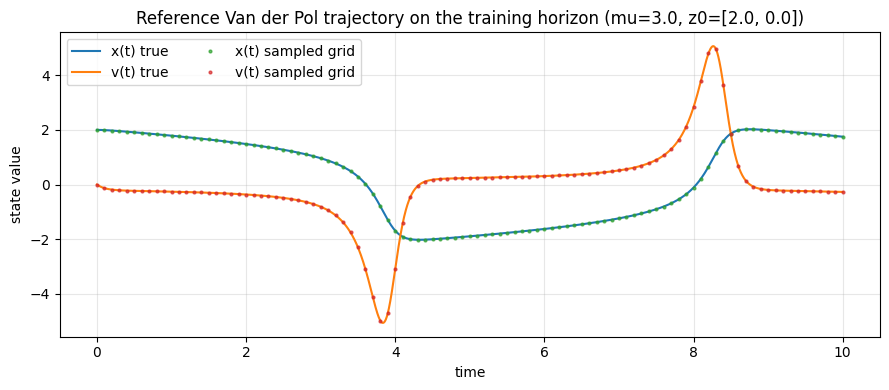

In [19]:
reference_true = solve_true_trajectory(REFERENCE_Z0, t_eval=T_EVAL)
reference_true_dense = solve_true_trajectory(REFERENCE_Z0, t_eval=T_EVAL_PLOT)

plt.figure(figsize=(9, 4))
plt.plot(T_EVAL_PLOT, reference_true_dense[:, 0], label="x(t) true")
plt.plot(T_EVAL_PLOT, reference_true_dense[:, 1], label="v(t) true")
plt.plot(T_EVAL, reference_true[:, 0], "o", ms=2, alpha=0.7, label="x(t) sampled grid")
plt.plot(T_EVAL, reference_true[:, 1], "o", ms=2, alpha=0.7, label="v(t) sampled grid")
plt.xlabel("time")
plt.ylabel("state value")
plt.title(f"Reference Van der Pol trajectory on the training horizon (mu={MU}, z0={REFERENCE_Z0.tolist()})")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()

path = RESULTS_DIR / "reference_traj_dense.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

## True phase portrait of the Van der Pol system

This figure shows an actual phase portrait of the **true** Van der Pol system: the vector field is
shown with a streamplot and the reference trajectory is integrated on a longer horizon so the
relaxation transient and the approach toward the limit cycle are visible.

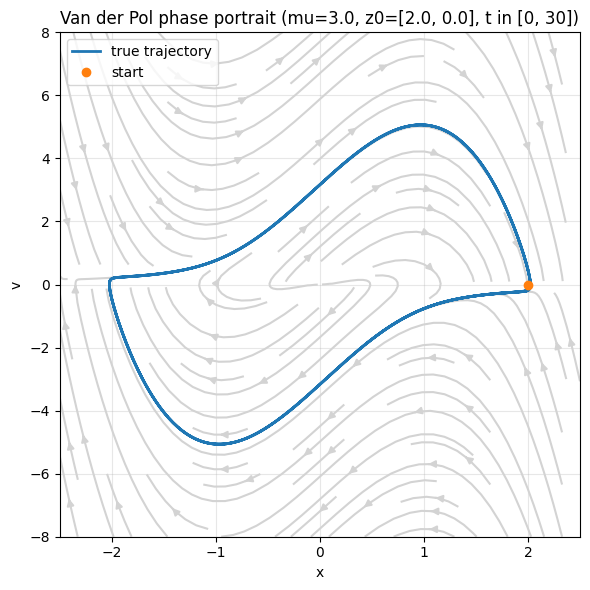

In [20]:
phase_true = solve_true_trajectory(REFERENCE_Z0, t_eval=T_EVAL_PHASE)

xg = np.linspace(PHASE_FIELD_XLIM[0], PHASE_FIELD_XLIM[1], PHASE_FIELD_N)
vg = np.linspace(PHASE_FIELD_VLIM[0], PHASE_FIELD_VLIM[1], PHASE_FIELD_N)
X, V = np.meshgrid(xg, vg)
dX = V
dV = MU * (1.0 - X**2) * V - X

plt.figure(figsize=(6, 6))
plt.streamplot(X, V, dX, dV, density=1.0, color="lightgray")
plt.plot(phase_true[:, 0], phase_true[:, 1], linewidth=2, label="true trajectory")
plt.plot(phase_true[0, 0], phase_true[0, 1], "o", label="start")
plt.xlabel("x")
plt.ylabel("v")
plt.title(f"Van der Pol phase portrait (mu={MU}, z0={REFERENCE_Z0.tolist()}, t in [{T0:.0f}, {PHASE_TRAJ_T1:.0f}])")
plt.xlim(*PHASE_FIELD_XLIM)
plt.ylim(*PHASE_FIELD_VLIM)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

path = RESULTS_DIR / "true_phase_portrait.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

## Trajectory comparison in phase space for a representative seed

The next figure compares the short-horizon rollouts used in the experiment. The **true** trajectory
is plotted densely on the training horizon, while the learned models are shown on the original
training grid so the comparison does not change the learned discrete-time rollout.

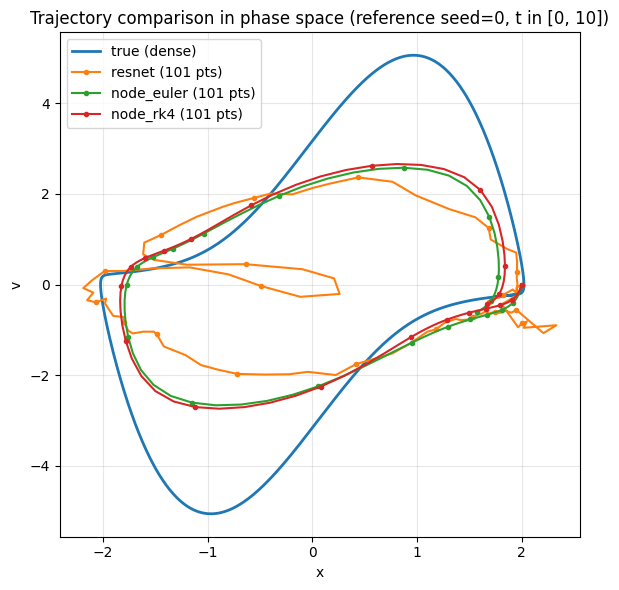

In [21]:
if reference_models is not None:
    z0_tensor = torch.from_numpy(REFERENCE_Z0[None, :]).to(device)

    plt.figure(figsize=(6, 6))
    plt.plot(reference_true_dense[:, 0], reference_true_dense[:, 1], label="true (dense)", linewidth=2)

    for model_name in MAIN_MODEL_ORDER:
        model = reference_models[model_name].to(device)
        model.eval()
        with torch.no_grad():
            pred = model(z0_tensor).cpu().numpy()[0]
        plt.plot(
            pred[:, 0],
            pred[:, 1],
            "o-",
            ms=PHASE_MARKER_SIZE,
            markevery=PHASE_MARK_EVERY,
            label=f"{model_name} ({N_TIME} pts)",
        )

    plt.xlabel("x")
    plt.ylabel("v")
    plt.title(f"Trajectory comparison in phase space (reference seed={REFERENCE_SEED}, t in [{T0:.0f}, {T1:.0f}])")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    path = RESULTS_DIR / "trajectory_rollout_phase_space_comparison.png"
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("Reference models were not captured.")

## Boxplot of test loss across seeds

/var/folders/g9/zqlb1j1d6g15cvmc1d9q7c6c0000gn/T/ipykernel_31420/195537474.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=MAIN_MODEL_ORDER)


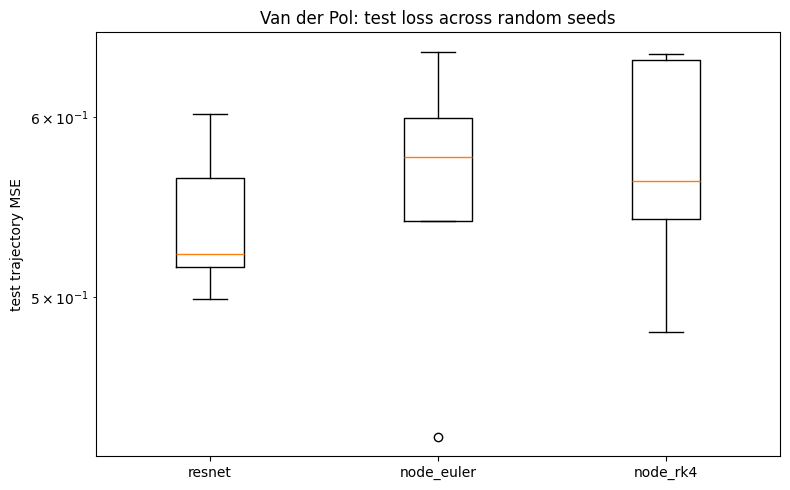

In [22]:
plt.figure(figsize=(8, 5))

data = [results_df.loc[results_df["model"] == m, "test_loss"].values for m in MAIN_MODEL_ORDER]

plt.boxplot(data, labels=MAIN_MODEL_ORDER)
plt.yscale("log")
plt.ylabel("test trajectory MSE")
plt.title("Van der Pol: test loss across random seeds")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

path = RESULTS_DIR / "boxplot_test_loss.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()


## Paired-seed test-loss plot

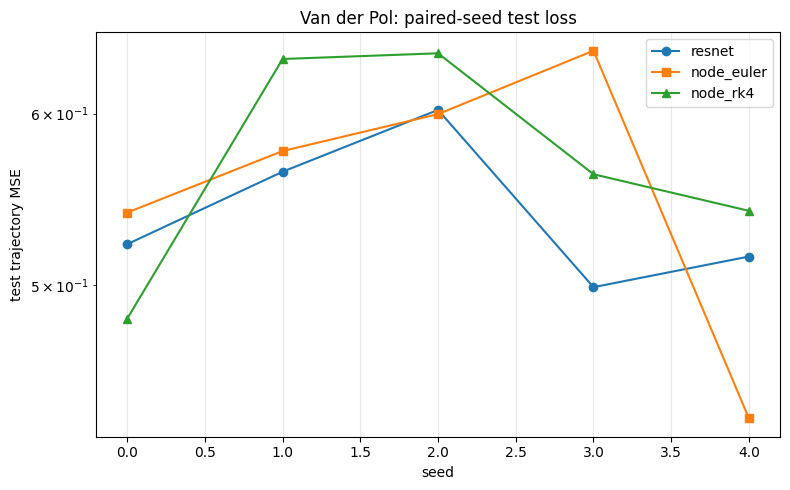

In [23]:
paired_df = (
    results_df.pivot(index="seed", columns="model", values="test_loss")
    .reindex(columns=MAIN_MODEL_ORDER)
    .sort_index()
)

markers = {"resnet": "o", "node_euler": "s", "node_rk4": "^"}

plt.figure(figsize=(8, 5))
for model_name in MAIN_MODEL_ORDER:
    plt.plot(
        paired_df.index,
        paired_df[model_name],
        marker=markers.get(model_name, "o"),
        label=model_name,
    )

plt.yscale("log")
plt.xlabel("seed")
plt.ylabel("test trajectory MSE")
plt.title("Van der Pol: paired-seed test loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

path = RESULTS_DIR / "paired_seed_test_loss.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()


## Scatter plot of validation vs test loss

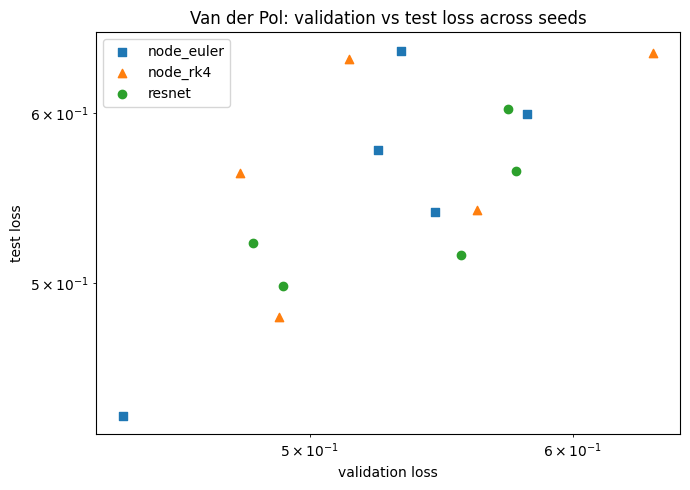

In [24]:
plt.figure(figsize=(7, 5))

markers = {"resnet": "o", "node_euler": "s", "node_rk4": "^"}

for model_name, group in results_df.groupby("model"):
    plt.scatter(group["val_loss"], group["test_loss"], label=model_name, marker=markers.get(model_name, "o"))

plt.xscale("log")
plt.yscale("log")
plt.xlabel("validation loss")
plt.ylabel("test loss")
plt.title("Van der Pol: validation vs test loss across seeds")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

path = RESULTS_DIR / "val_vs_test_scatter.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()


## Mean validation-loss curves across seeds

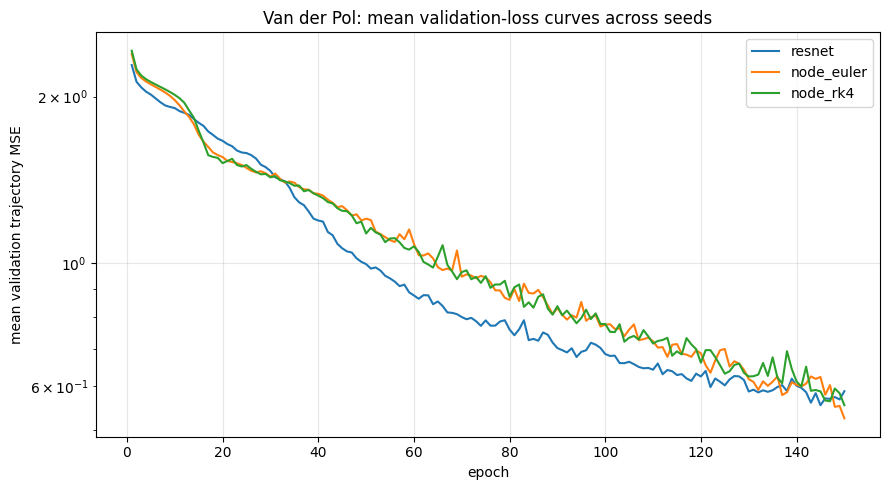

In [25]:
if histories_df is not None:
    grouped_hist = (
        histories_df.groupby(["model", "epoch"])
        .agg(
            train_loss_mean=("train_loss", "mean"),
            train_loss_std=("train_loss", "std"),
            val_loss_mean=("val_loss", "mean"),
            val_loss_std=("val_loss", "std"),
        )
        .reset_index()
    )

    plt.figure(figsize=(9, 5))
    for model_name in MAIN_MODEL_ORDER:
        group = grouped_hist[grouped_hist["model"] == model_name]
        plt.plot(group["epoch"], group["val_loss_mean"], label=model_name)

    plt.yscale("log")
    plt.xlabel("epoch")
    plt.ylabel("mean validation trajectory MSE")
    plt.title("Van der Pol: mean validation-loss curves across seeds")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    path = RESULTS_DIR / "mean_validation_loss_curves.png"
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("No histories available.")
